# Exercice 2 — Q-Learning « from scratch » avec une Q-table

## Objectif

Dans l'exercice 1, c'est **Stable-Baselines3** qui contenait l'algorithme d'apprentissage : on appelait `.learn()` sans savoir ce qu'il y avait dedans. Ici, **on ouvre la boîte noire** : on code nous-mêmes le **Q-Learning**.


On va :
1. Créer l'environnement **FrozenLake-v1** et initialiser une **Q-table** (tableau `NumPy`).
2. Coder la **boucle d'entraînement** : stratégie *epsilon-greedy* + mise à jour de **Bellman**.
3. **Évaluer** l'agent entraîné et mesurer son **taux de réussite**.


## L'environnement FrozenLake

Un lac gelé en grille **4×4**. L'agent part en haut à gauche (`S`) et doit atteindre le cadeau en bas à droite (`G`) **sans tomber dans un trou** (`H`).

```
 S  F  F  F      S = Start  (départ, état 0)
 F  H  F  H      F = Frozen (glace : on peut marcher)
 F  F  F  H      H = Hole   (trou → chute, épisode perdu)
 H  F  F  G      G = Goal   (objectif → +1, épisode gagné)
```

- **16 états** : les cases numérotées de `0` (haut-gauche) à `15` (bas-droite).
- **4 actions** : `0` = ← GAUCHE, `1` = ↓ BAS, `2` = → DROITE, `3` = ↑ HAUT.
- **Récompense** : `+1` **uniquement** en atteignant le but ; `0` partout ailleurs (y compris en tombant dans un trou). C'est une récompense **rare** (*sparse*) → le signal d'apprentissage est difficile à obtenir.

> **Le lac est glissant** (`is_slippery=True` par défaut) : quand on choisit une direction, on n'y va **qu'une fois sur trois** ; les deux autres fois, on dérape sur un côté ! L'environnement est donc **stochastique**. Conséquence : même la meilleure stratégie possible ne gagne pas à 100 % — un excellent agent plafonne autour de **70–80 %** de réussite. (On peut passer `is_slippery=False` pour un lac déterministe où viser 100 %.)


## Le Q-Learning en 3 idées

### 1. La Q-table : la « qualité » de chaque choix

La **Q-table** est un tableau `16 lignes × 4 colonnes`. La case `Q[état, action]` estime la **récompense totale future** espérée si, depuis cet `état`, on joue cette `action` (puis qu'on continue de bien jouer). Au départ on ne sait rien → **toutes les cases valent 0**. L'entraînement va les remplir petit à petit.

Une fois la table apprise, **agir** devient trivial : dans un état, on prend l'action de **plus grande valeur Q** (`np.argmax`).

### 2. Explorer ou exploiter ? La stratégie *epsilon-greedy*

Dilemme central du RL : faut-il **exploiter** ce qu'on croit être le meilleur choix, ou **explorer** au hasard pour découvrir mieux ?

- avec probabilité **ε** (*epsilon*) → on **explore** (action aléatoire) ;
- avec probabilité **1 − ε** → on **exploite** (`np.argmax` de la Q-table).

Au début `ε = 1` (exploration totale), puis on le fait **décroître** : à mesure que l'agent apprend, il explore moins et exploite davantage.

### 3. La mise à jour de Bellman

Après chaque transition `(état, action) → (récompense, nouvel_état)`, on corrige la valeur Q :

$$Q[s, a] \;\leftarrow\; Q[s, a] \;+\; \alpha \,\Big( \; \underbrace{r + \gamma \max_{a'} Q[s', a']}_{\text{cible}} \;-\; \underbrace{Q[s, a]}_{\text{prédiction actuelle}} \Big)$$

En Python :
```python
q_table[state, action] += lr * (reward + gamma * np.max(q_table[new_state]) - q_table[state, action])
```

- **`lr` (α, *learning rate*)** : ampleur de la correction à chaque pas (0 = on n'apprend pas ; 1 = on remplace tout).
- **`gamma` (γ, *discount factor*)** : importance des récompenses **futures** vs immédiates (proche de 1 = vision long terme).
- **`r + γ·max Q[s']`** : la **cible** — la récompense reçue *plus* la meilleure valeur atteignable depuis le nouvel état.
- **le terme entre parenthèses** est l'**erreur de prédiction** (*TD error*) : l'écart entre la prédiction et la cible ; on pousse `Q` dans cette direction.


## Étape 1 — Créer l'environnement et initialiser la Q-table


In [1]:
import numpy as np
import gymnasium as gym

# is_slippery=True par défaut -> lac glissant (stochastique).
env = gym.make("FrozenLake-v1", is_slippery=True)

# Reproductibilité (facultatif) : on fixe les graines aléatoires.
np.random.seed(42)
env.action_space.seed(42)
env.reset(seed=42)

# Dimensions récupérées DYNAMIQUEMENT depuis l'environnement.
n_etats = env.observation_space.n     # 16
n_actions = env.action_space.n        # 4

# La Q-table : une ligne par état, une colonne par action. Tout à zéro au départ.
q_table = np.zeros((n_etats, n_actions))

print(f"Nombre d'états   : {n_etats}")
print(f"Nombre d'actions : {n_actions}")
print(f"Forme de la Q-table : {q_table.shape}")
print(q_table)

Nombre d'états   : 16
Nombre d'actions : 4
Forme de la Q-table : (16, 4)
[[0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]]


## Les hyperparamètres

Ce sont les réglages de l'apprentissage. Ces valeurs donnent un bon résultat sur FrozenLake glissant (~70–75 % de réussite)

>**Pourquoi un `learning_rate` faible (0.1) ?** Le lac est **glissant** : une même action donne des résultats différents d'une fois à l'autre.  
>Avec un `alpha` élevé (ex. 0.8), chaque mise à jour **surréagirait** au hasard d'un seul essai et les valeurs Q « sauteraient » partout (résultat instable, ~55 %).  
>Un `alpha` faible **moyenne** l'information sur de nombreux essais → apprentissage bien plus stable (~75 %).


In [ ]:
# --- Durée d'entraînement ---
n_episodes_entrainement = 20000   # nombre de parties jouées pour apprendre
max_pas_par_episode = 100         # garde-fou : longueur max d'un épisode (NOTRE boucle) - valeur max par défaut dans l'environnement : 100


# --- Formule de mise à jour (Bellman) ---
learning_rate = 0.1      # alpha : correction DOUCE (crucial car le lac est glissant)
discount_factor = 0.99   # gamma : on valorise fortement les récompenses futures

# --- Stratégie d'exploration (epsilon-greedy) ---
epsilon = 1.0            # epsilon de départ : 100 % d'exploration au début
max_epsilon = 1.0        # valeur maximale (au tout début)
min_epsilon = 0.05       # on garde toujours un petit peu d'exploration
decay_rate = 0.0005      # vitesse de décroissance de epsilon

## Étape 2 — La boucle d'entraînement

Pour chaque épisode : on repart du départ, puis à chaque pas on **choisit** une action (*epsilon-greedy*), on **agit**, et on **met à jour** la Q-table (Bellman).  
À la fin de l'épisode, on **réduit epsilon**.

On enregistre aussi la récompense de chaque épisode (0 ou 1) pour tracer ensuite la courbe d'apprentissage.


In [ ]:
# On (ré)initialise la Q-table, espsilon et les récompenses par épisode avant l'entraînement (au cas où on relancerait le code).
q_table = np.zeros((n_etats, n_actions))
epsilon = max_epsilon

recompenses_par_episode = []   # 0 ou 1 pour chaque épisode -> courbe d'apprentissage

for episode in range(n_episodes_entrainement):
    # Nouvel épisode : on repart de l'état de départ.
    state, info = env.reset()
    terminated = truncated = False
    recompense_episode = 0.0

    for pas in range(max_pas_par_episode):
        # --- Choix de l'action : EPSILON-GREEDY ---
        if np.random.uniform(0, 1) < epsilon:
            action = env.action_space.sample()          # EXPLORATION (au hasard)
        else:
            action = np.argmax(q_table[state, :])       # EXPLOITATION (meilleure connue)

        # --- On exécute l'action ---
        new_state, reward, terminated, truncated, info = env.step(action)

        # --- Mise à jour de la Q-table : formule de Bellman ---
        # Q[s,a] <- Q[s,a] + lr * ( r + gamma * max_a' Q[s',a'] - Q[s,a] )
        q_table[state, action] = q_table[state, action] + learning_rate * (reward + discount_factor * np.max(q_table[new_state, :]) - q_table[state, action])

        state = new_state              # on avance vers le nouvel état
        recompense_episode += reward
        if terminated or truncated:    # trou ou but atteint -> fin de l'épisode
            break

    # --- Fin d'épisode : on réduit epsilon (moins d'exploration au fil du temps) ---
    epsilon = min_epsilon + (max_epsilon - min_epsilon) * np.exp(-decay_rate * episode)
    recompenses_par_episode.append(recompense_episode)

print("Entraînement terminé.")
print(f"Réussite moyenne sur les 1000 derniers épisodes : "
      f"{np.mean(recompenses_par_episode[-1000:]):.1%}")
print(f"epsilon final : {epsilon:.3f}")

Entraînement terminé.
Réussite moyenne sur les 1000 derniers épisodes : 53.3%
epsilon final : 0.050


## Visualiser l'apprentissage

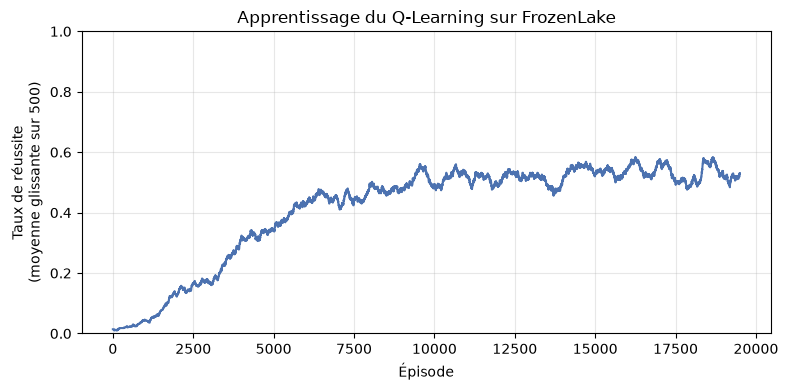

In [4]:
import matplotlib.pyplot as plt

recompenses = np.array(recompenses_par_episode)
fenetre = 500
# moyenne glissante = taux de réussite lissé sur `fenetre` épisodes
taux_glissant = np.convolve(recompenses, np.ones(fenetre) / fenetre, mode="valid")

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(taux_glissant, color="#4C72B0")
ax.set_xlabel("Épisode")
ax.set_ylabel(f"Taux de réussite\n(moyenne glissante sur {fenetre})")
ax.set_title("Apprentissage du Q-Learning sur FrozenLake")
ax.set_ylim(0, 1)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Étape 3 — Évaluer l'agent entraîné

On mesure maintenant les performances **sans jamais explorer** : à chaque pas, l'agent joue toujours sa meilleure action connue (`np.argmax`).  
On compte les victoires (récompense de `1.0`) sur un grand nombre d'épisodes.


In [5]:
n_episodes_eval = 1000    # plus il y en a, plus l'estimation du taux est fiable
victoires = 0

for episode in range(n_episodes_eval):
    state, info = env.reset()          # réinitialisation à chaque épisode
    terminated = truncated = False

    for pas in range(max_pas_par_episode):
        # TOUJOURS exploiter : aucune exploration en évaluation (plus de epsilon).
        action = np.argmax(q_table[state, :])
        state, reward, terminated, truncated, info = env.step(action)
        if terminated or truncated:
            if reward == 1.0:          # l'épisode s'est terminé sur le but
                victoires += 1
            break

taux_reussite = victoires / n_episodes_eval
print(f"Taux de réussite sur {n_episodes_eval} épisodes : {taux_reussite:.1%}")

Taux de réussite sur 1000 épisodes : 73.3%


## À quoi ressemble la Q-table apprise ?

Deux façons de la lire :
- la **table brute** des valeurs Q (16 états × 4 actions) sous forme de *heatmap* ;
- la **politique** qui en découle : pour chaque case du lac, la flèche = meilleure action (`np.argmax`). C'est la « stratégie » que l'agent a apprise.


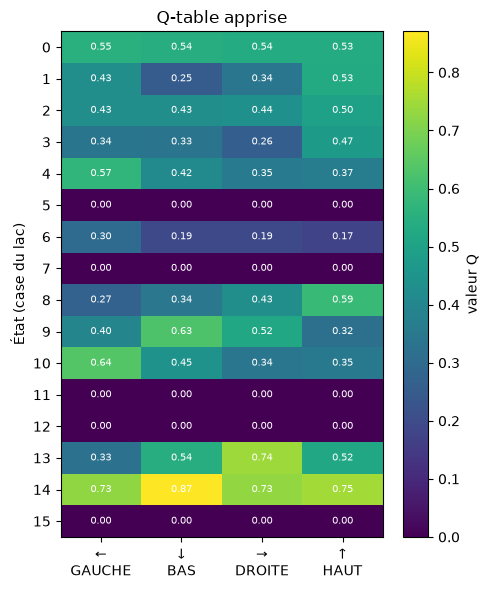

Politique apprise (meilleure action par case) :

 ← | ↑ | ↑ | ↑ 
 ← | H | ← | H 
 ↑ | ↓ | ← | H 
 H | → | ↓ | G 


In [6]:
import matplotlib.pyplot as plt

# --- (a) Heatmap de la Q-table ---
fig, ax = plt.subplots(figsize=(5, 6))
im = ax.imshow(q_table, cmap="viridis", aspect="auto")
ax.set_xticks(range(4))
ax.set_xticklabels(["←\nGAUCHE", "↓\nBAS", "→\nDROITE", "↑\nHAUT"])
ax.set_yticks(range(16))
ax.set_ylabel("État (case du lac)")
ax.set_title("Q-table apprise")
for i in range(16):
    for j in range(4):
        ax.text(j, i, f"{q_table[i, j]:.2f}", ha="center", va="center",
                color="white", fontsize=7)
fig.colorbar(im, ax=ax, label="valeur Q")
plt.tight_layout()
plt.show()

# --- (b) Politique déduite, affichée sur la grille 4x4 ---
fleches = ["←", "↓", "→", "↑"]
desc = env.unwrapped.desc          # carte en octets : b'S', b'F', b'H', b'G'
print("Politique apprise (meilleure action par case) :\n")
for ligne in range(4):
    cases = []
    for col in range(4):
        etat = ligne * 4 + col
        lettre = desc[ligne, col]
        if lettre == b"H":
            cases.append(" H ")                                  # trou
        elif lettre == b"G":
            cases.append(" G ")                                  # but
        else:
            cases.append(f" {fleches[np.argmax(q_table[etat])]} ")
    print("|".join(cases))

## Bonus — Voir l'agent jouer : réussite et échec

On filme l'agent entraîné en capturant **un épisode gagné** *et* **un épisode perdu**, pour comparer. Le lac étant glissant, l'agent perd parfois même en jouant parfaitement — c'est instructif de le voir.

### Le vocabulaire de cette cellule (les formulations utiles à connaître)

- **`render_mode="rgb_array"`** : on demande à l'environnement de produire des **images**. Chaque `env.render()` renvoie alors un tableau de pixels `(hauteur, largeur, 3)` (les 3 = Rouge/Vert/Bleu). Sans cette option, `render()` ne renvoie rien.
- **`max_episode_steps=...`** : la limite de temps **interne** de l'environnement. FrozenLake s'arrête tout seul au bout de **100 pas par défaut** (et met alors `truncated=True`). Ta variable `max_pas_par_episode` ne pilote que *ta* boucle `for/while` ; pour vraiment autoriser 200 pas, il faut relever **cette** limite-ci. **C'était le paramètre manquant.**
- **`terminated` vs `truncated`** (rappel) : `terminated` = fin liée à la tâche (on tombe dans un trou `H`, ou on atteint le but `G`) ; `truncated` = fin liée au temps (limite de pas atteinte).
- **`q_table[state, :]`** : la notation `[state, :]` prend **toute la ligne** `state` de la Q-table, soit les **4 valeurs Q** (une par action) de l'état courant. Le `:` veut dire « toutes les colonnes ».
- **`np.argmax(...)`** : renvoie l'**indice** (0, 1, 2 ou 3) de la plus grande valeur → l'action jugée la meilleure. (`np.max` donnerait la *valeur* ; `argmax` donne sa *position*.)
- **le motif `None` (« sentinelle »)** : on initialise `frames_reussite = None` (« pas encore trouvé »), puis on teste `if frames_reussite is None`. Manière classique de dire « je n'ai pas encore de résultat ».
- **`imageio.mimsave(chemin, images, fps=3)`** : assemble la liste d'images en un **GIF animé** (`mim` = *multiple images*), à 3 images/seconde.
- **`display(Image(filename=...))`** : affiche le fichier image directement dans la sortie de la cellule.
- **une fonction `def ...()`** : on regroupe le code répété (jouer un épisode ; sauver+afficher un GIF) dans de petites fonctions réutilisables → plus lisible que de copier-coller.


/home/raya-kevin/agent-workspace/projects/11_PROJET_11/P_11/.venv/lib/python3.12/site-packages/pygame/pkgdata.py:25: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import resource_stream, resource_exists


✅ Réussite — 32 pas :


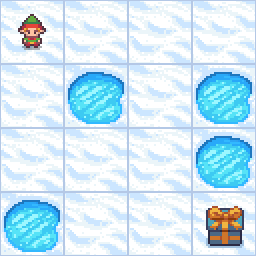

❌ Échec — 19 pas :


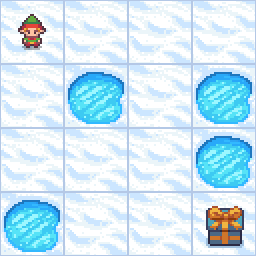

In [7]:
import os
os.environ.setdefault("SDL_VIDEODRIVER", "dummy")   # rendu "sans écran" (pas de fenêtre)
import imageio.v2 as imageio                          # assemble des images en fichier GIF
from IPython.display import Image, display            # affiche une image dans le notebook

# On recrée l'environnement en mode IMAGE. Deux points importants :
#   - render_mode="rgb_array" : chaque appel env.render() renvoie une IMAGE (tableau de
#     pixels de forme (hauteur, largeur, 3) en RVB) au lieu de ne rien renvoyer.
#   - max_episode_steps : on RELÈVE la limite de temps interne de l'environnement
#     (100 par défaut !) pour autoriser des épisodes plus longs -> ici jusqu'à 200 pas.
env_viz = gym.make(
    "FrozenLake-v1",
    is_slippery=True,
    render_mode="rgb_array",
    max_episode_steps=max_pas_par_episode,   # <-- LE paramètre à ne pas oublier
)


def jouer_un_episode():
    """Joue UN épisode avec la politique apprise (toujours la meilleure action) et
    renvoie deux choses : la liste des images capturées, et un booléen "a gagné ?"."""
    state, info = env_viz.reset()
    images = [env_viz.render()]                      # image de l'état de départ
    terminated = truncated = False
    reward = 0.0
    # On joue jusqu'à la fin : terminated (trou/but) OU truncated (temps écoulé).
    while not (terminated or truncated):
        action = np.argmax(q_table[state, :])        # exploitation pure : meilleure action connue
        state, reward, terminated, truncated, info = env_viz.step(action)
        images.append(env_viz.render())              # on capture l'image après le pas
    a_gagne = (reward == 1.0)                         # gagné = épisode fini sur le but (récompense 1)
    return images, a_gagne


# But : capturer UN exemple de chaque -> une réussite ET un échec.
# On part de "rien trouvé" (None) et on rejoue jusqu'à avoir les deux (ou 500 essais max).
frames_reussite = None
frames_echec = None
essai = 0
while (frames_reussite is None or frames_echec is None) and essai < 500:
    images, a_gagne = jouer_un_episode()
    if a_gagne and frames_reussite is None:          # on garde la 1re réussite rencontrée
        frames_reussite = images
    elif not a_gagne and frames_echec is None:       # et le 1er échec rencontré
        frames_echec = images
    essai += 1
env_viz.close()


def sauver_et_afficher(images, chemin, titre):
    """Sauvegarde la liste d'images en GIF animé, puis l'affiche dans le notebook."""
    if images is None:
        print(f"{titre} : aucun épisode de ce type trouvé.")
        return
    imageio.mimsave(chemin, images, fps=3)           # fps=3 -> 3 images/seconde (lecture lente)
    print(f"{titre} — {len(images) - 1} pas :")
    display(Image(filename=chemin))


# Deux GIF DISTINCTS (deux noms de fichier différents !), affichés l'un après l'autre.
sauver_et_afficher(frames_reussite, "frozenlake_reussite.gif", "✅ Réussite")
sauver_et_afficher(frames_echec,    "frozenlake_echec.gif",    "❌ Échec")